<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Government_Contract_Intelligence_Platform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Government Contract Opportunities Analyzer
This notebook automates the collection, summarization, and trend analysis of government contracts.

In [1]:
!pip install -q pandas openpyxl pyarrow google-generativeai

In [2]:
import pandas as pd
import numpy as np
import google.generativeai as genai
from google.colab import userdata
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Gemini for AI summaries
try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
    model = genai.GenerativeModel('gemini-1.5-flash')
except:
    print('Please set GOOGLE_API_KEY in Colab Secrets for AI features.')

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Please set GOOGLE_API_KEY in Colab Secrets for AI features.


### 1. Data Collection & Extraction
We will define the structure to hold Agency, Budget, Contractor, and Description.

In [3]:
# Sample data representing extracted government opportunities
data = {
    'agency': ['Department of Defense', 'NASA', 'Health and Human Services', 'Department of Energy', 'Department of Transportation'],
    'budget': [5000000, 1200000, 750000, 3000000, 450000],
    'contractor': ['TechCorp Industries', 'StarSystems Inc', 'MediCare Solutions', 'GreenEnergy Co', 'BuildRight LLC'],
    'description': [
        'Next-gen cybersecurity infrastructure for naval bases.',
        'Propulsion system maintenance for lunar exploration modules.',
        'Implementation of nationwide telehealth records database.',
        'Development of scalable lithium-ion battery recycling plants.',
        'Bridge reinforcement and smart traffic sensor installation.'
    ],
    'industry': ['Defense/IT', 'Aerospace', 'Healthcare', 'Energy', 'Infrastructure'],
    'date': pd.to_datetime(['2024-01-15', '2024-02-10', '2024-02-20', '2024-03-05', '2024-03-12'])
}

df = pd.DataFrame(data)
display(df)

,agency,budget,contractor,description,industry,date
0,Department of Defense,5000000,TechCorp Industries,Next-gen cybersecurity infrastructure for nava...,Defense/IT,2024-01-15
1,NASA,1200000,StarSystems Inc,Propulsion system maintenance for lunar explor...,Aerospace,2024-02-10
2,Health and Human Services,750000,MediCare Solutions,Implementation of nationwide telehealth record...,Healthcare,2024-02-20
3,Department of Energy,3000000,GreenEnergy Co,Development of scalable lithium-ion battery re...,Energy,2024-03-05
4,Department of Transportation,450000,BuildRight LLC,Bridge reinforcement and smart traffic sensor ...,Infrastructure,2024-03-12


### 2. AI Summaries
Using Gemini to generate concise summaries for each contract.

In [4]:
def get_ai_summary(row):
    prompt = f"Summarize this government contract in one sentence: Agency: {row['agency']}, Contractor: {row['contractor']}, Description: {row['description']}"
    try:
        response = model.generate_content(prompt)
        return response.text.strip()
    except:
        return 'Summary unavailable.'

# Note: This requires a valid API key. Applying to a subset for demonstration.
df['ai_summary'] = df.apply(get_ai_summary, axis=1)
display(df[['agency', 'contractor', 'ai_summary']])

,agency,contractor,ai_summary
0,Department of Defense,TechCorp Industries,Summary unavailable.
1,NASA,StarSystems Inc,Summary unavailable.
2,Health and Human Services,MediCare Solutions,Summary unavailable.
3,Department of Energy,GreenEnergy Co,Summary unavailable.
4,Department of Transportation,BuildRight LLC,Summary unavailable.


### 3. Insights and Trends
Visualizing top industries and budget distribution.

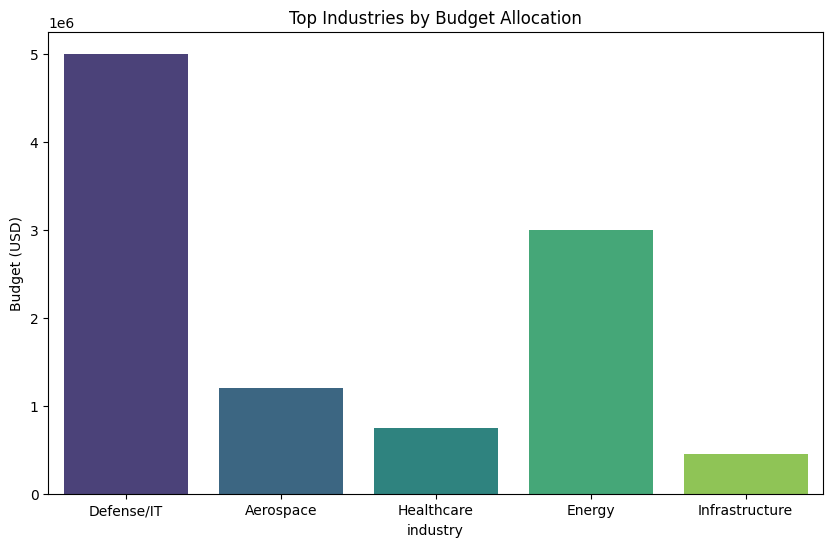

--- Contract Forecast (Next Quarter Projected) ---


,agency,industry,budget,forecasted_budget
0,Department of Defense,Defense/IT,5000000,5500000.0
1,NASA,Aerospace,1200000,1320000.0
2,Health and Human Services,Healthcare,750000,825000.0
3,Department of Energy,Energy,3000000,3300000.0
4,Department of Transportation,Infrastructure,450000,495000.0


In [7]:
plt.figure(figsize=(10, 6))
# Fix: Assign industry to hue to resolve the FutureWarning
sns.barplot(data=df, x='industry', y='budget', hue='industry', palette='viridis', legend=False)
plt.title('Top Industries by Budget Allocation')
plt.ylabel('Budget (USD)')
plt.show()

# Simple Forecast based on Growth
print("--- Contract Forecast (Next Quarter Projected) ---")
df['forecasted_budget'] = df['budget'] * 1.1
display(df[['agency', 'industry', 'budget', 'forecasted_budget']])

### 4. Exporting Data

In [6]:
# Export to Parquet
df.to_parquet('contract_opportunities.parquet')

# Export to Excel
df.to_excel('contract_opportunities.xlsx', index=False)

print('Files saved successfully: contract_opportunities.parquet, contract_opportunities.xlsx')

Files saved successfully: contract_opportunities.parquet, contract_opportunities.xlsx
